In [43]:
import pandas as pd
import numpy as np

# fetching the data from downloaded abalone txt
file_path = "abalone_data.txt"
column_names = [
    "Sex", "Length", "Diameter", "Height", "Whole_weight",
    "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"
]
df = pd.read_csv(file_path, names=column_names)

# creating the Age variable (defined from UCI)
df['Age'] = df['Rings'] + 1.5

# Market Value Proxy
diam_75 = df['Diameter'].quantile(0.75)
weight_75 = df['Whole_weight'].quantile(0.75)
diam_25 = df['Diameter'].quantile(0.25)
weight_25 = df['Whole_weight'].quantile(0.25)

# logical conditions for each market tier
conditions = [
    (df['Diameter'] >= diam_75) & (df['Whole_weight'] >= weight_75), # premium
    (df['Diameter'] >= diam_25) & (df['Whole_weight'] >= weight_25)  # standard
]

# assigning base prices for premium, standard, and sub-standard
base_prices = [50.0, 30.0, 15.0]

# applying the conditions to create a base price column
df['Base_Price'] = np.select(conditions, base_prices[:-1], default=base_prices[-1])

# noise: epsilon ~ N(0, sigma^2)
# using a standard deviation of 3 to represent realistic price fluctuation
np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=3.0, size=len(df))

# calculating final market value, rounding it, and clipping at 0 to prevent negative prices
df['Market_Value'] = np.round(df['Base_Price'] + noise, 2)
df['Market_Value'] = df['Market_Value'].clip(lower=0)

# dropping the intermediate base price column to keep the dataframe clean
df.drop(columns=['Base_Price'], inplace=True)

# organizing and separating the data for specific modeling tasks
targets = df[['Age', 'Market_Value']]
pca_features = df[['Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']]
remaining_predictors = df[['Sex', 'Length', 'Diameter', 'Height']]

# Verify the output
print("Data preview:")
print(df[['Diameter', 'Whole_weight', 'Age', 'Market_Value']].head())

Data preview:
   Diameter  Whole_weight   Age  Market_Value
0     0.365        0.5140  16.5         31.49
1     0.265        0.2255   8.5         14.59
2     0.420        0.6770  10.5         31.94
3     0.365        0.5160  11.5         34.57
4     0.255        0.2050   8.5         14.30


Loaded shape: (4177, 11)
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings   Age  Market_Value  
0         0.150     15  16.5         31.49  
1         0.070      7   8.5         14.59  
2         0.210      9  10.5         31.94  
3         0.155     10  11.5         34.57  
4         0.055      7   8.5         14.30  

Missing values:
Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
Age               0
M

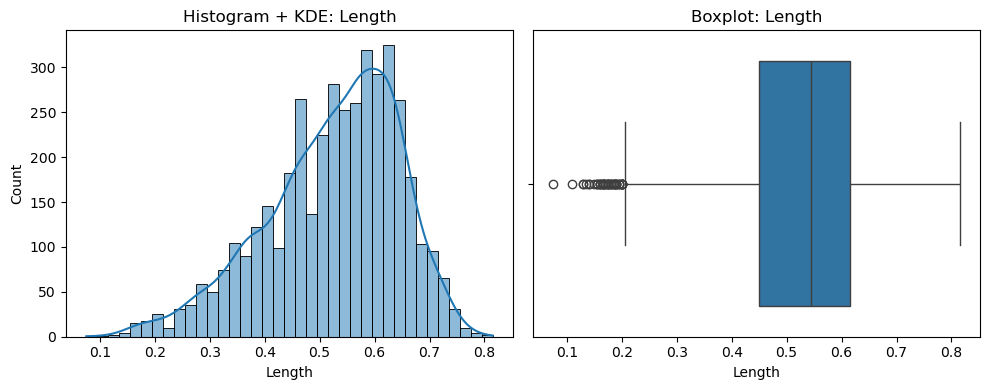


--- Diameter ---
Mean: 0.4079
Median: 0.4250
Std: 0.0992
Skewness: -0.6090
Outliers (IQR method): 59


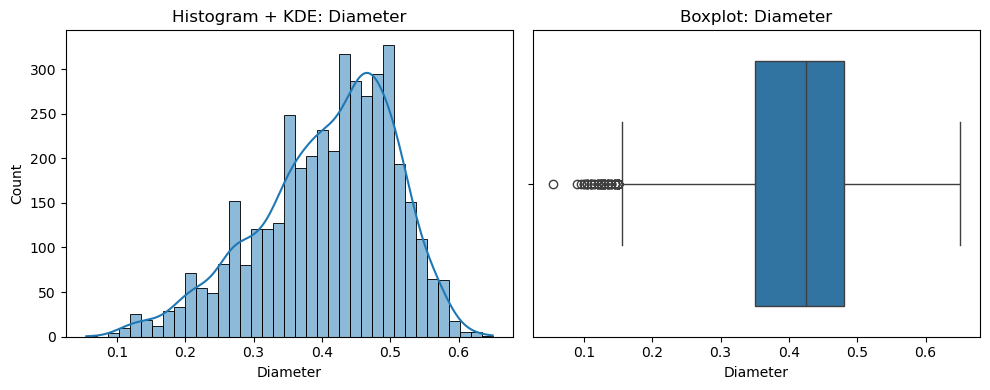


--- Height ---
Mean: 0.1395
Median: 0.1400
Std: 0.0418
Skewness: 3.1277
Outliers (IQR method): 29


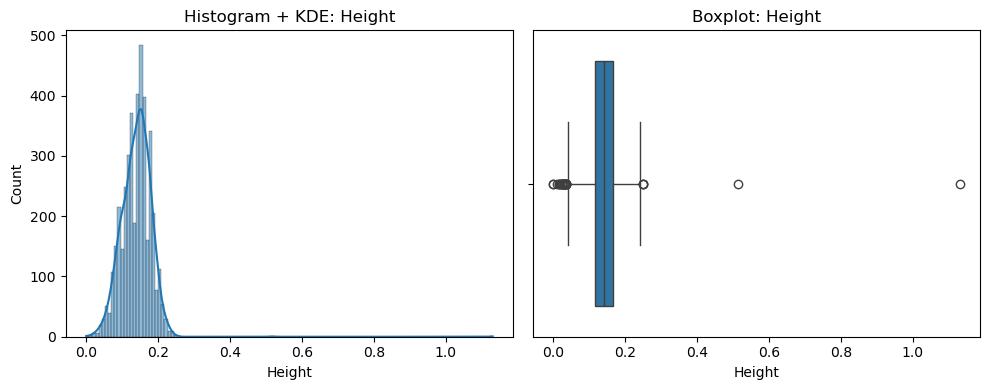


--- Whole_weight ---
Mean: 0.8287
Median: 0.7995
Std: 0.4904
Skewness: 0.5308
Outliers (IQR method): 30


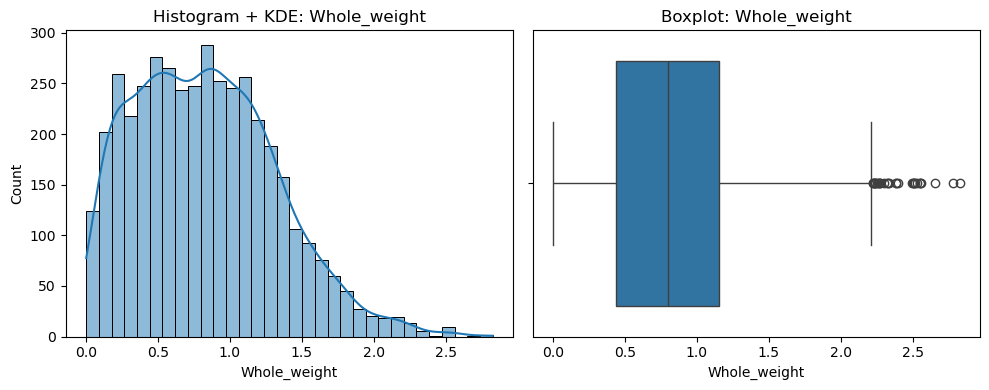


--- Shucked_weight ---
Mean: 0.3594
Median: 0.3360
Std: 0.2220
Skewness: 0.7188
Outliers (IQR method): 48


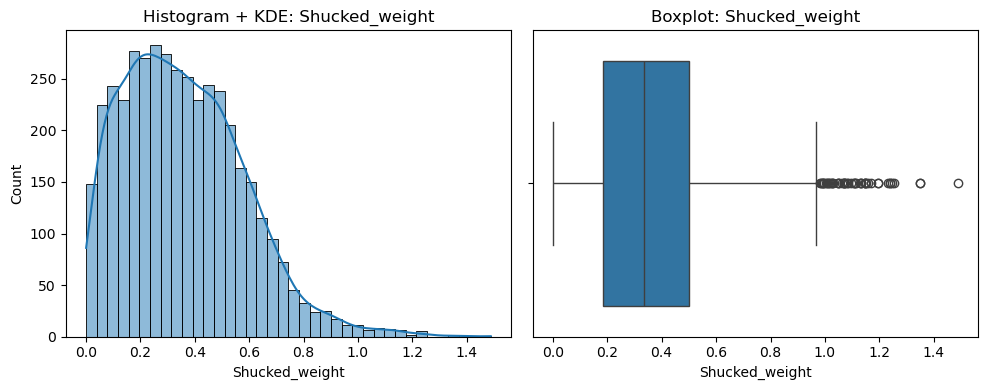


--- Viscera_weight ---
Mean: 0.1806
Median: 0.1710
Std: 0.1096
Skewness: 0.5916
Outliers (IQR method): 26


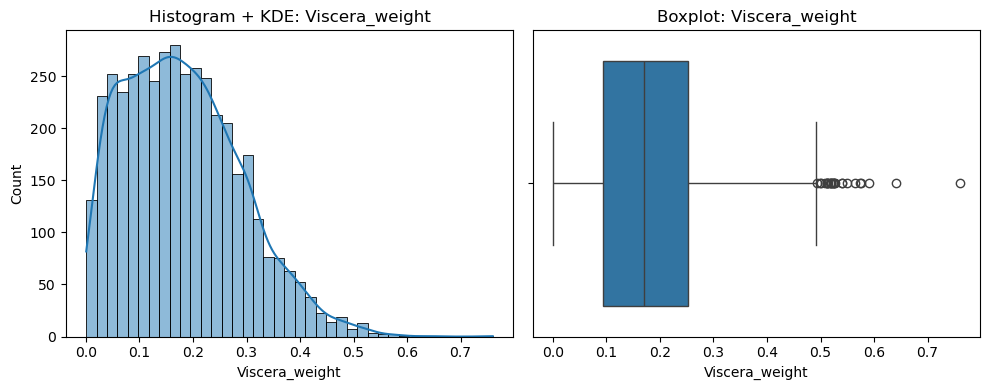


--- Shell_weight ---
Mean: 0.2388
Median: 0.2340
Std: 0.1392
Skewness: 0.6207
Outliers (IQR method): 35


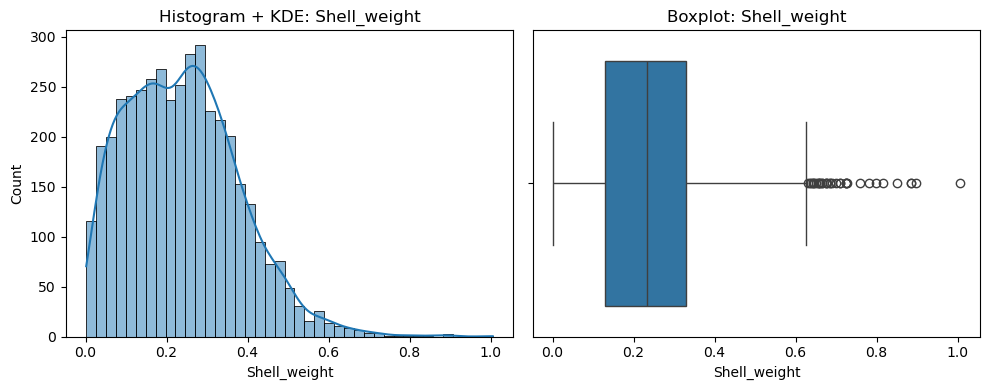


--- Rings ---
Mean: 9.9337
Median: 9.0000
Std: 3.2242
Skewness: 1.1137
Outliers (IQR method): 278


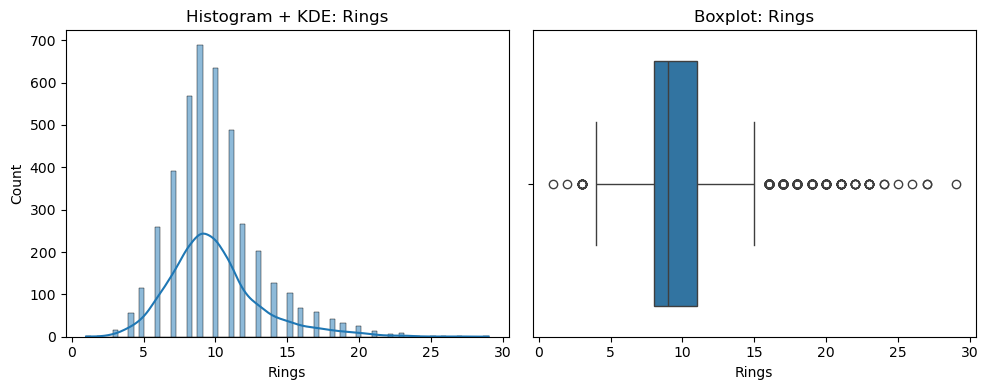


--- Age ---
Mean: 11.4337
Median: 10.5000
Std: 3.2242
Skewness: 1.1137
Outliers (IQR method): 278


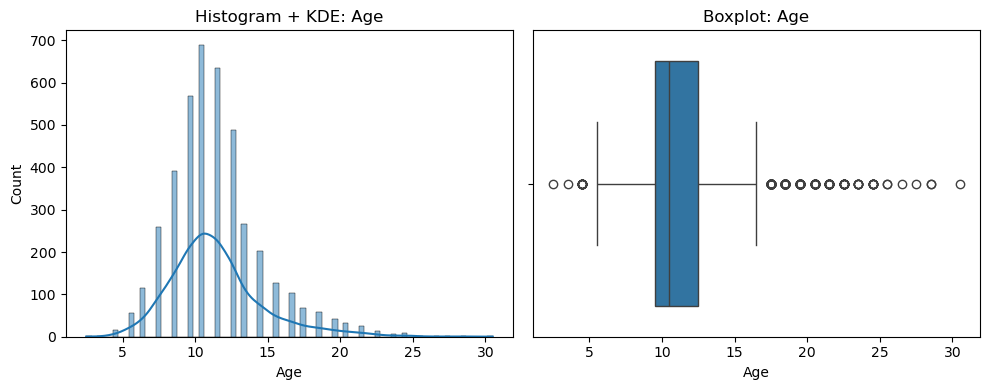


--- Market_Value ---
Mean: 30.5361
Median: 29.7500
Std: 12.5788
Skewness: 0.3500
Outliers (IQR method): 9


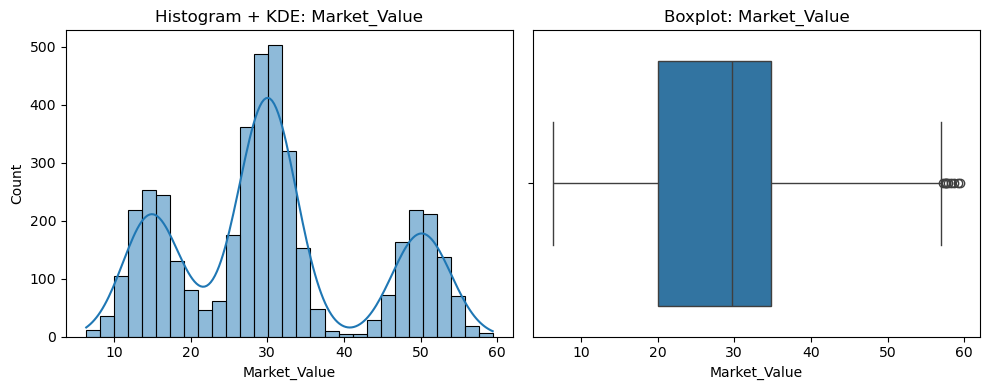

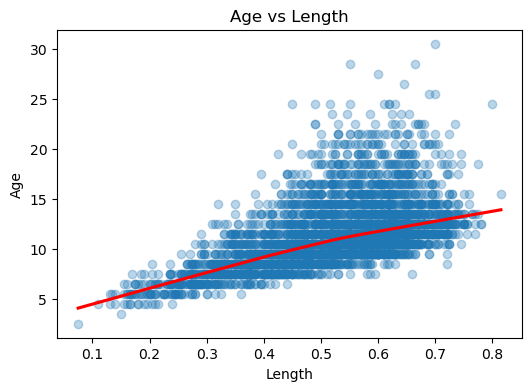

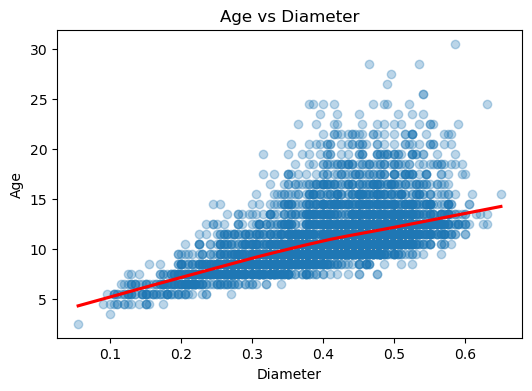

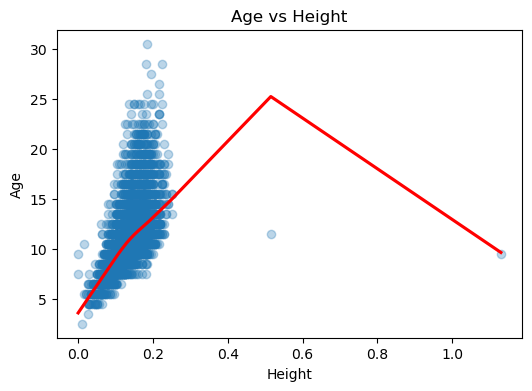

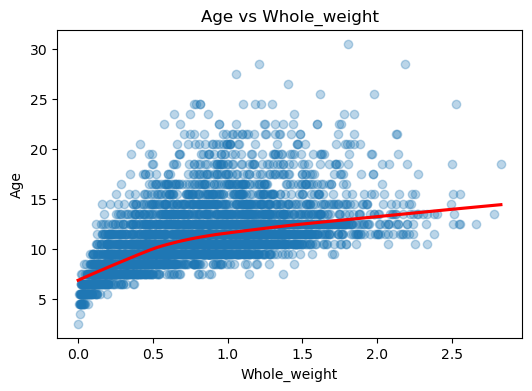

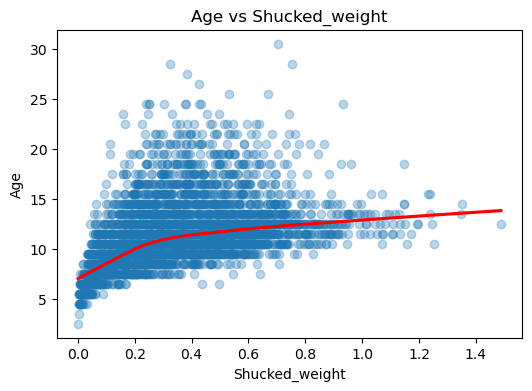

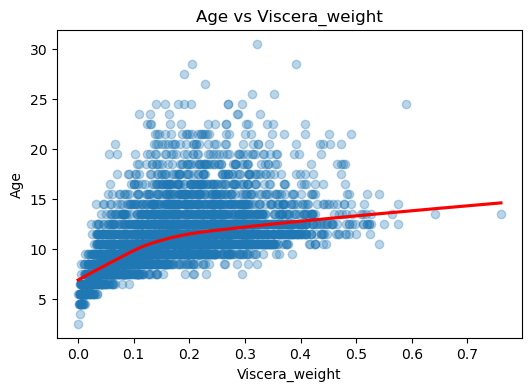

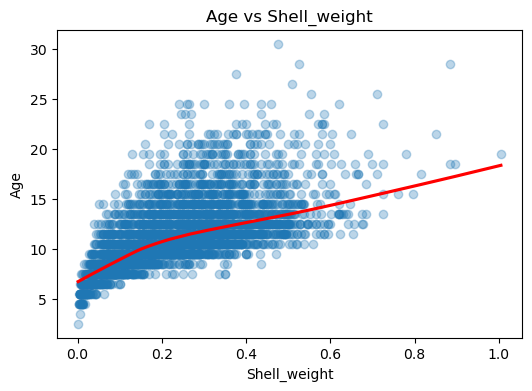

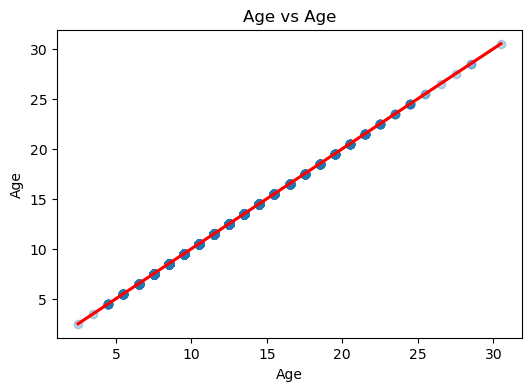

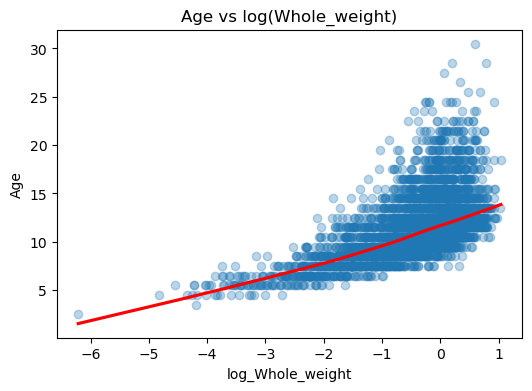

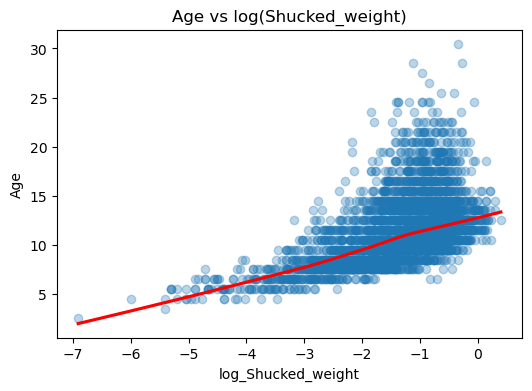

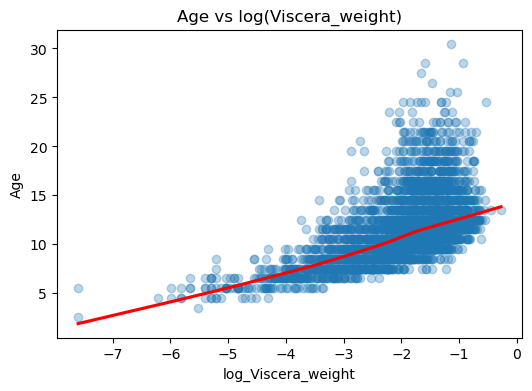

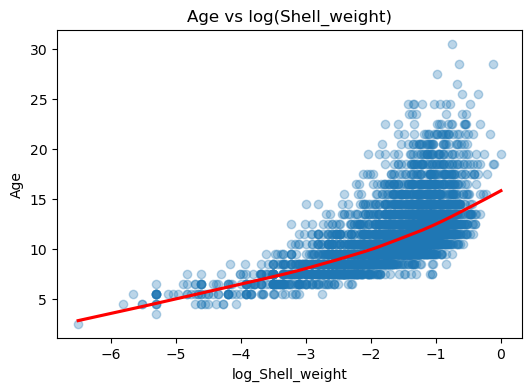

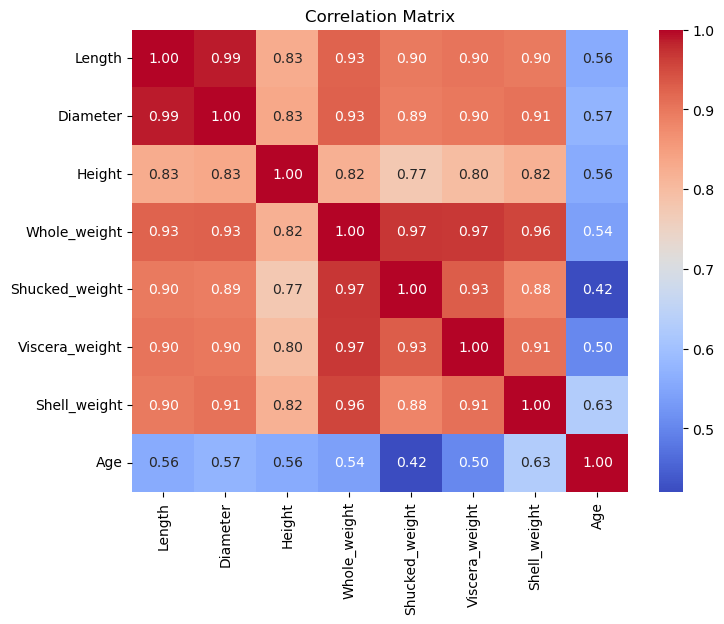

          Feature         VIF
0           const   65.605491
1          Length   40.779070
2        Diameter   42.203488
3          Height    3.609767
4    Whole_weight  113.780726
5  Shucked_weight   32.452813
6  Viscera_weight   17.582701
7    Shell_weight   21.548538
8             Age    2.116984


In [44]:
"""
Abalone Dataset Exploratory Data Analysis
"""

import seaborn as sns
from scipy.stats import skew
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Loaded shape:", df.shape)
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(f"\n--- {col} ---")

    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    skewness = skew(df[col])

    print(f"Mean: {mean:.4f}")
    print(f"Median: {median:.4f}")
    print(f"Std: {std:.4f}")
    print(f"Skewness: {skewness:.4f}")

    #IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"Outliers (IQR method): {len(outliers)}")

    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram + KDE: {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()

predictors = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Age"
]

for col in predictors:
    plt.figure(figsize=(6, 4))
    sns.regplot(
        x=df[col],
        y=df["Age"],
        lowess=True,
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )
    plt.title(f"Age vs {col}")
    plt.show()

for col in ["Whole_weight", "Shucked_weight",
            "Viscera_weight", "Shell_weight"]:
    df[f"log_{col}"] = np.log(df[col] + 1e-6)

    plt.figure(figsize=(6, 4))
    sns.regplot(
        x=df[f"log_{col}"],
        y=df["Age"],
        lowess=True,
        scatter_kws={"alpha": 0.3},
        line_kws={"color": "red"}
    )
    plt.title(f"Age vs log({col})")
    plt.show()

predictors = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Age"
]

corr = df[predictors].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

X = df[predictors]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

In [45]:
def cap_outliers_iqr(df, columns):
    df_capped = df.copy()

    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # cap values
        df_capped[col] = df_capped[col].clip(lower, upper)

        print(f"{col}: capped to [{lower:.3f}, {upper:.3f}]")

    return df_capped

numeric_cols = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight"
]

df = cap_outliers_iqr(df, numeric_cols)
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "remaining outliers:", len(outliers))


Length: capped to [0.203, 0.862]
Diameter: capped to [0.155, 0.675]
Height: capped to [0.040, 0.240]
Whole_weight: capped to [-0.626, 2.220]
Shucked_weight: capped to [-0.288, 0.976]
Viscera_weight: capped to [-0.146, 0.492]
Shell_weight: capped to [-0.168, 0.627]
Length remaining outliers: 0
Diameter remaining outliers: 0
Height remaining outliers: 0
Whole_weight remaining outliers: 0
Shucked_weight remaining outliers: 0
Viscera_weight remaining outliers: 0
Shell_weight remaining outliers: 0


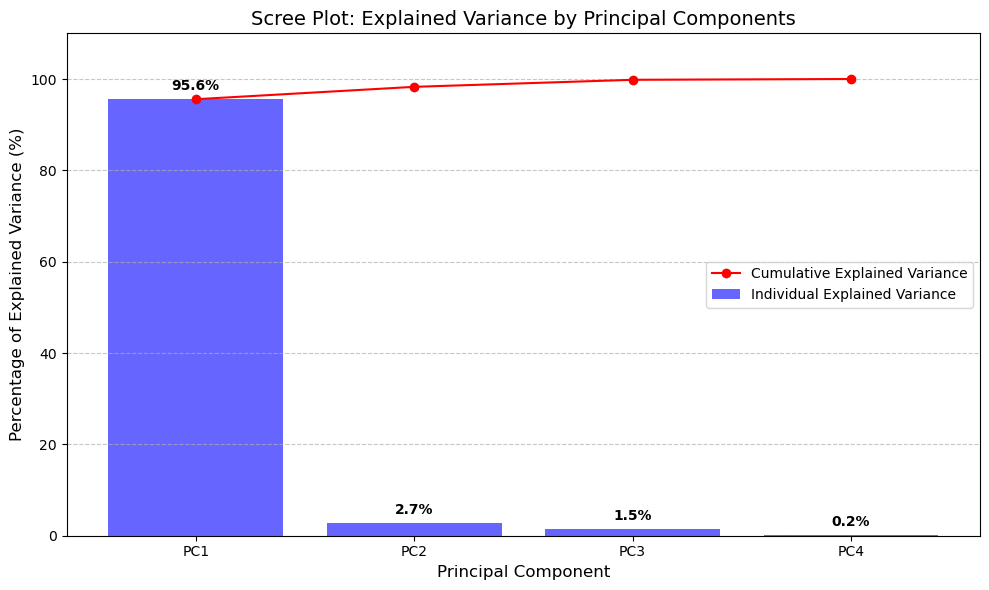

PCA Loadings (Eigenvectors):
                     PC1       PC2       PC3       PC4
Whole_weight    0.509958 -0.008116 -0.109419  0.853173
Shucked_weight  0.497135 -0.588974 -0.519190 -0.369336
Viscera_weight  0.499614 -0.182660  0.824089 -0.194677
Shell_weight    0.493139  0.787197 -0.198361 -0.312710


In [46]:
## DUE TO LARGE VIF WE MOVE TO PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# isolating the collinear weight variables
weight_cols = ['Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
X_weights = df[weight_cols]

# standardize again
scaler = StandardScaler()
X_weights_scaled = scaler.fit_transform(X_weights)

# fit the PCA model
# We have 4 original variables, so we can calculate up to 4 principal components
pca = PCA(n_components=4)
pca.fit(X_weights_scaled)

# calc the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

# create the Scree Plot
plt.figure(figsize=(10, 6))

# plot individual variance
plt.bar(range(1, 5), explained_variance, alpha=0.6, color='b', label='Individual Explained Variance')

# plot cumulative variance
plt.plot(range(1, 5), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')

plt.title('Scree Plot: Explained Variance by Principal Components', fontsize=14)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Percentage of Explained Variance (%)', fontsize=12)
plt.xticks([1, 2, 3, 4], ['PC1', 'PC2', 'PC3', 'PC4'])
plt.ylim(0, 110)
plt.legend(loc='center right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# annotate the bar chart with exact percentages
for i, var in enumerate(explained_variance):
    plt.text(i + 1, var + 2, f"{var:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# extracting the Principal Components
# also printing the loadings to see how the original variables contribute to PC1
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
    index=weight_cols
)
print("PCA Loadings (Eigenvectors):")
print(loadings)

In [47]:
import statsmodels.api as sm
import pandas as pd

# transform the original scaled weights into Principal Components
components = pca.transform(X_weights_scaled)

# extract PC1 and PC2 and append them to the main dataframe
# PC1 represents "Overall Mass" and PC2 represents the "Meat-to-Shell Ratio"
df['PC1_Overall_Mass'] = components[:, 0]
df['PC2_Meat_Ratio'] = components[:, 1]

# drop the highly collinear original weight columns
weight_cols = ['Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
df_reduced = df.drop(columns=weight_cols)

# handle Categorical Data
# the 'Sex' column contains categories (M, F, I for Infant)
df_reduced = pd.get_dummies(df_reduced, columns=['Sex'], drop_first=True)

#define Predictors (X) and Target (y) for predicting Age
# also including the remaining size variables, the two principal components, and the Sex dummy variables
X = df_reduced[['Length', 'Diameter', 'Height', 'PC1_Overall_Mass', 'PC2_Meat_Ratio', 'Sex_I', 'Sex_M']]

X = X.astype(float)

y_age = df_reduced['Age'] # target variable

# add a constant (intercept) to the matrix
X_with_const = sm.add_constant(X)

# fit the Baseline Multiple Linear Regression Model
# OLS to minimize the sum of squared residuals
mlr_age_model = sm.OLS(y_age, X_with_const).fit()

# print the comprehensive statistical summary
print(mlr_age_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    Age   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     664.8
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:51:37   Log-Likelihood:                -9250.7
No. Observations:                4177   AIC:                         1.852e+04
Df Residuals:                    4169   BIC:                         1.857e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.4662      0.468  

#### Decision Tree Regressor and Feature Importance

Best Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}

--- Decision Tree Performance ---
Test R-squared: 0.5333
Test RMSE: 2.2477 Rings


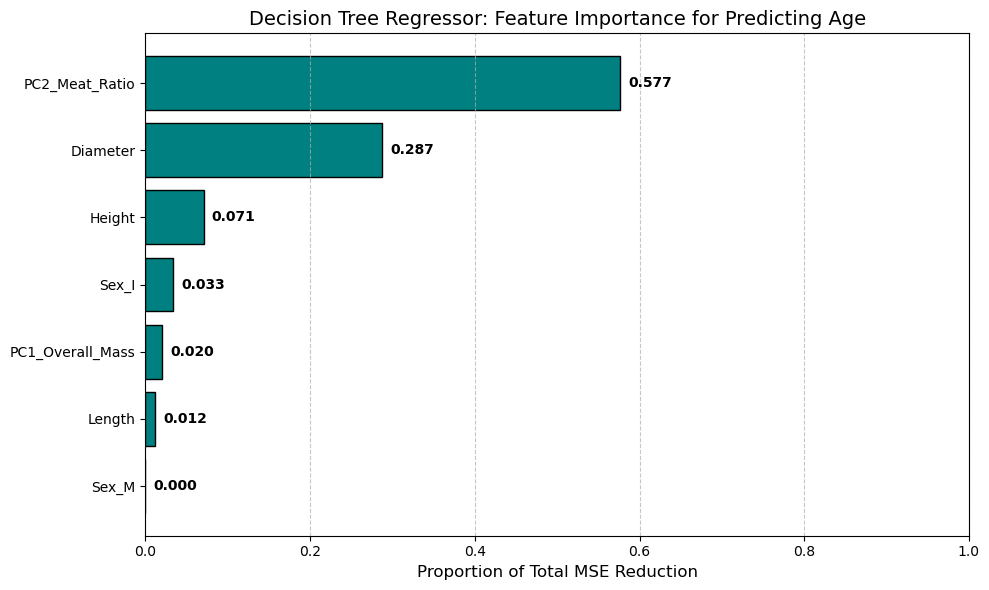

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# assuming 'X' (without the constant) and 'y_age' are still in your environment from Step 5
# X currently contains: Length, Diameter, Height, PC1_Overall_Mass, PC2_Meat_Ratio, Sex_I, Sex_M

# train/Test Split (80% training, 20% testing)
# This is crucial for evaluating true predictive power on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y_age, test_size=0.2, random_state=42)

# hyperparameter Tuning using Grid Search
# we will test different maximum depths and minimum samples required to split a node
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# initialize the regressor
dt = DecisionTreeRegressor(random_state=42)

# run the grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# extract the Best Model
best_dt_model = grid_search.best_estimator_
print(f"Best Tree Parameters: {grid_search.best_params_}")

# evaluate the Model on the Unseen Test Data
y_pred = best_dt_model.predict(X_test)
dt_r2 = r2_score(y_test, y_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Decision Tree Performance ---")
print(f"Test R-squared: {dt_r2:.4f}")
print(f"Test RMSE: {dt_rmse:.4f} Rings")

# extract and visualize Feature Importance
importances = best_dt_model.feature_importances_
feature_names = X.columns

# creating a DataFrame for easy sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# plotting the Feature Importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal', edgecolor='black')
plt.title('Decision Tree Regressor: Feature Importance for Predicting Age', fontsize=14)
plt.xlabel('Proportion of Total MSE Reduction', fontsize=12)
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.01, index, f"{value:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Best Tree Parameters (Price): {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}

--- Market Value Prediction Performance ---
Test R-squared: 0.8464
Test RMSE: $4.99


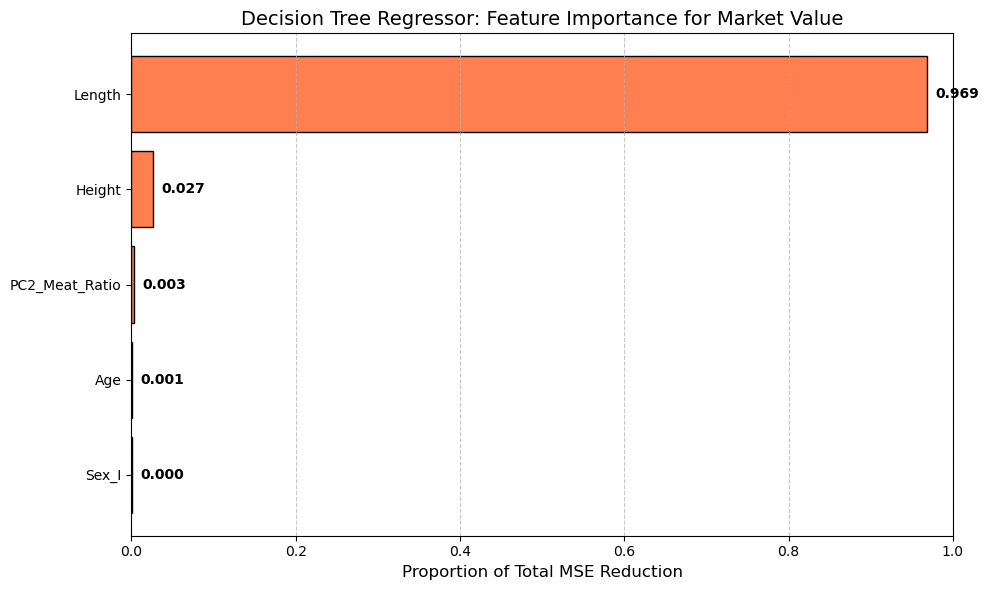

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# define the new Predictors (X) and Target (y)
# also dropping PC1 to prevent data leakage. Adding Age again.
X_price = df_reduced[['Age', 'Length', 'Height', 'PC2_Meat_Ratio', 'Sex_I']]
y_price = df_reduced['Market_Value']

# train/test split (80% training, 20% testing)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

# hyperparameter Tuning using Grid Search
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20]
}

dt_price = DecisionTreeRegressor(random_state=42)
grid_search_price = GridSearchCV(
    estimator=dt_price, param_grid=param_grid,
    cv=5, scoring='r2', n_jobs=-1
)
grid_search_price.fit(X_train_p, y_train_p)

# extracting the best model and evaluate
best_price_model = grid_search_price.best_estimator_
y_pred_p = best_price_model.predict(X_test_p)

price_r2 = r2_score(y_test_p, y_pred_p)
price_rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_p))

print(f"Best Tree Parameters (Price): {grid_search_price.best_params_}")
print("\n--- Market Value Prediction Performance ---")
print(f"Test R-squared: {price_r2:.4f}")
print(f"Test RMSE: ${price_rmse:.2f}")

# feature importance
importances_p = best_price_model.feature_importances_
feature_names_p = X_price.columns

importance_df_p = pd.DataFrame({'Feature': feature_names_p, 'Importance': importances_p})
importance_df_p = importance_df_p.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_p['Feature'], importance_df_p['Importance'], color='coral', edgecolor='black')
plt.title('Decision Tree Regressor: Feature Importance for Market Value', fontsize=14)
plt.xlabel('Proportion of Total MSE Reduction', fontsize=12)
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(importance_df_p['Importance']):
    plt.text(value + 0.01, index, f"{value:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()